# Introducción a K-Means

Este notebook está pensado para **estudiar el algoritmo K-Means paso a paso** usando un dataset de familias con **ingresos, gastos y ahorro**.

## Indicaciones
Intenta responder a estos puntos.
- Comprender qué problema resuelve K-Means.
- Explorar el dataset antes de agrupar.
- Seleccionar variables con criterio.
- Entender por qué hay que escalar los datos.
- Aplicar K-Means con distintos valores de `k`.
- Utilizar el método Elbow (del codo)
- Interpretar los centroides y los clusters.

> Nota: comenta cada resultado antes de pasar a la siguiente.

## 1. Cargar librerías y dataset

En esta primera parte cargamos:
- el dataset de familias,
- las librerías de análisis,
- y una vista inicial de los datos.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [55]:
# Cambia la ruta si guardas el CSV en otra carpeta
df = pd.read_csv("familias_gastos_ingresos_300.csv")
df.head()

,id_hogar,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,1,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,2,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,3,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,4,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,5,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


## 2. Primer vistazo al dataset

Antes de usar cualquier algoritmo, hay que entender los datos:
- cuántas filas hay,
- qué variables tenemos,
- si hay valores nulos,
- y qué magnitudes manejamos.

In [56]:
#filas
df.shape

(300, 9)

In [57]:
#variables
df.columns

Index(['id_hogar', 'ingreso_anual', 'gasto_vivienda', 'gasto_alimentacion',
       'gasto_transporte', 'gasto_ocio', 'gasto_salud', 'gasto_educacion',
       'ahorro'],
      dtype='object')

In [58]:
#cómo son los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_hogar            300 non-null    int64  
 1   ingreso_anual       300 non-null    float64
 2   gasto_vivienda      300 non-null    float64
 3   gasto_alimentacion  300 non-null    float64
 4   gasto_transporte    300 non-null    float64
 5   gasto_ocio          300 non-null    float64
 6   gasto_salud         300 non-null    float64
 7   gasto_educacion     300 non-null    float64
 8   ahorro              300 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 21.2 KB


In [59]:
#hay nulos o no
df.isnull().sum()

id_hogar              0
ingreso_anual         0
gasto_vivienda        0
gasto_alimentacion    0
gasto_transporte      0
gasto_ocio            0
gasto_salud           0
gasto_educacion       0
ahorro                0
dtype: int64

## 3. Comprender el problema

K-Means es un algoritmo de **aprendizaje no supervisado**.
Eso significa que:
- no hay una columna objetivo,
- no hay etiquetas previas,
- y el objetivo es **descubrir grupos similares** en los datos.

En este caso queremos detectar perfiles de familias, por ejemplo:
- Familia tipo 1: .....
- Familia tipo 2: .....
- Familia tipo 3: .....

## 4. Selección inicial de variables

No siempre interesa usar todas las columnas desde el principio.
Para empezar, vamos a observar una relación muy intuitiva:

- `ingreso_anual`
- `gasto_ocio`

Esto permite una primera visualización sencilla del problema.

In [60]:
X_simple = df[["ingreso_anual", "gasto_ocio"]]
X_simple.head()

,ingreso_anual,gasto_ocio
0,35319.00,4041.16
1,53484.00,3031.31
2,50007.61,3666.31
3,39437.43,3600.76
4,12000.00,840.63


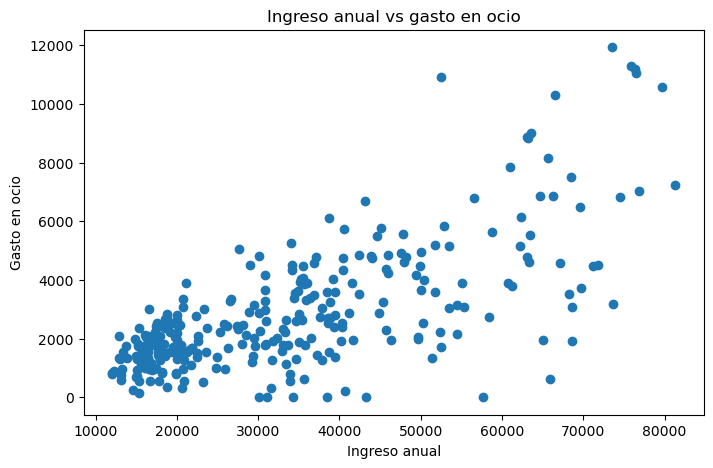

In [61]:
plt.figure(figsize=(8,5))
plt.scatter(df["ingreso_anual"], df["gasto_ocio"])
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("Ingreso anual vs gasto en ocio")
plt.show()

### Cuestiones
1. ¿Se distinguen grupos visualmente?
    -   A primera vista se distinguen tres grupos, el primero son las personas que cobran poco y gastan poco en ocio, el segundo cobran mas
        y gastan mas que los anteriores y el tercer grupo son los que cobran mas y su gasto en ocio es el mas alto de los tres grupos.

2. ¿Parece haber familias con ingresos parecidos pero distinto gasto en ocio?
    -   Si, hay personas que sus ingresos son parecidos pero su gasto en ocio es distinto pero no podemos comparar a personas con el mismo ingreso
        pero distinto gasto en ocio.

3. ¿Crees que con solo dos variables será suficiente?
    -   No es suficiente con el ingreso anual y el gasto en ocio anual, sacar el ahorro de cada persona, necesitamos los demas datos de gastos
        del dataset.


## 5. Primer K-Means con `k = 3`

Empieza con una prueba sencilla.
Aquí el algoritmo:
1. Fija un número de grupos `k`,
2. Busca centroides,
3. Asigna cada familia al centroide más cercano.

In [62]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X_simple)

labels_3 = kmeans_3.labels_
centroides_3 = kmeans_3.cluster_centers_

print("Centroides:")
print(centroides_3)

Centroides:
[[18685.46454545  1672.61075758]
 [63753.68980769  5573.08115385]
 [37749.7662069   2994.94077586]]


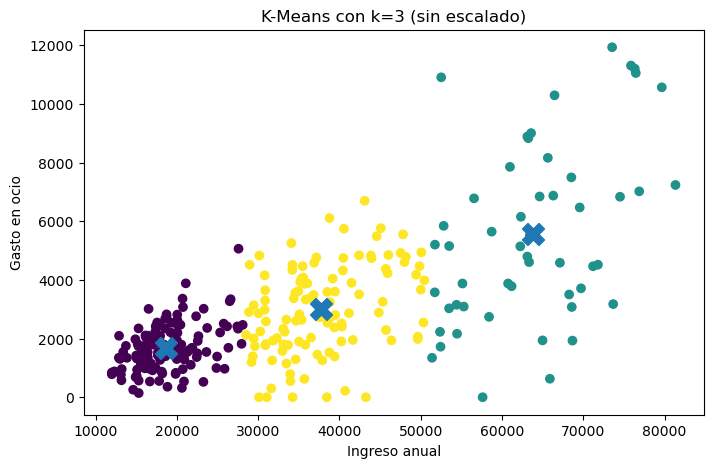

In [63]:
plt.figure(figsize=(8,5))
plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=labels_3)
plt.scatter(centroides_3[:,0], centroides_3[:,1], marker="X", s=250)
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("K-Means con k=3 (sin escalado)")
plt.show()

## 6. Interpretar los centroides

Los centroides representan el “centro” de cada grupo.

Conviene pasarlos a tabla para interpretarlos mejor.

In [64]:
pd.DataFrame(centroides_3, columns=X_simple.columns)

,ingreso_anual,gasto_ocio
0,18685.464545,1672.610758
1,63753.689808,5573.081154
2,37749.766207,2994.940776


### Cuestione
1. ¿Qué clúster tiene el mayor ingreso medio?
    -   El cluster que tiene el mayor ingreso medio es el segundo cluster con 63.753 ya que se concentran un gran numero de datos en comparacion con los otros 
        dos clster y sumando a que el ingreso de cada persona es alto, nos daria una media mas alta que los demas clusters.

2. ¿Cuál tiene menor gasto en ocio?
    -   El cluster que tiene menor gasto en ocio es el primer cluster ya que las personas se situan en primer lugar en el eje y (gasto ocio)

3. ¿Cómo describirías cada grupo con palabras?
    -   Hay perfiles de familias como: familias que no gastan porque no tienen (familias vulnerables), familias que gastan poco (ahorradoras), 
        familias que gatan mucho y cobran mucho (derrochadoras).


### Mas preguntas

4. ¿HAY RELACION ENTRE INGRESO Y GASTO?
    -   Se ve una cierta tendencia a que a medida que aumenta el ingreso aumenta el gasto aunque no es muy lineal, pero al ingresar mas gastas mas.

5. ¿QUE REPRESENTA CADA CLUSTER?:
    -   Cada grupo representan familias con gastos e ingresos similares.

## 7. Probar distintos valores de `k`

K-Means necesita que indiques el número de grupos.
Repite el proceso con distintos valores para ver cómo cambia el resultado.

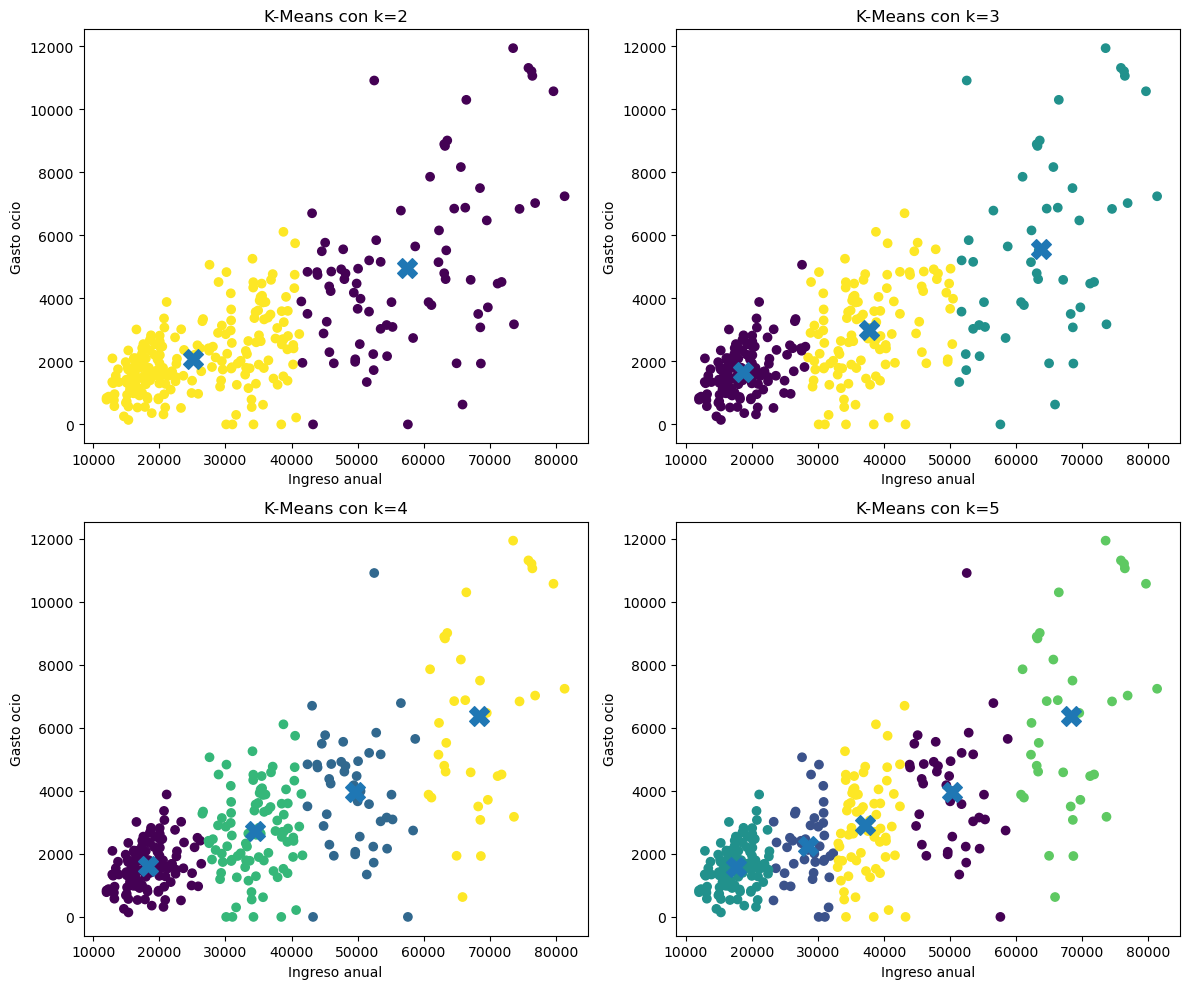

In [65]:
valores_k = [2, 3, 4, 5]

plt.figure(figsize=(12, 10))

for i, k in enumerate(valores_k, start=1):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_simple)
    centros = modelo.cluster_centers_

    plt.subplot(2, 2, i)
    plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=etiquetas)
    plt.scatter(centros[:,0], centros[:,1], marker="X", s=200)
    plt.title(f"K-Means con k={k}")
    plt.xlabel("Ingreso anual")
    plt.ylabel("Gasto ocio")

plt.tight_layout()
plt.show()

## 8. Método Elbow (Método del codo)

Una forma clásica de elegir `k` es calcular la **inercia** para distintos valores.
La inercia mide, en términos simples, lo compactos que quedan los grupos.

Buscamos el punto en que la mejora deja de ser tan grande.

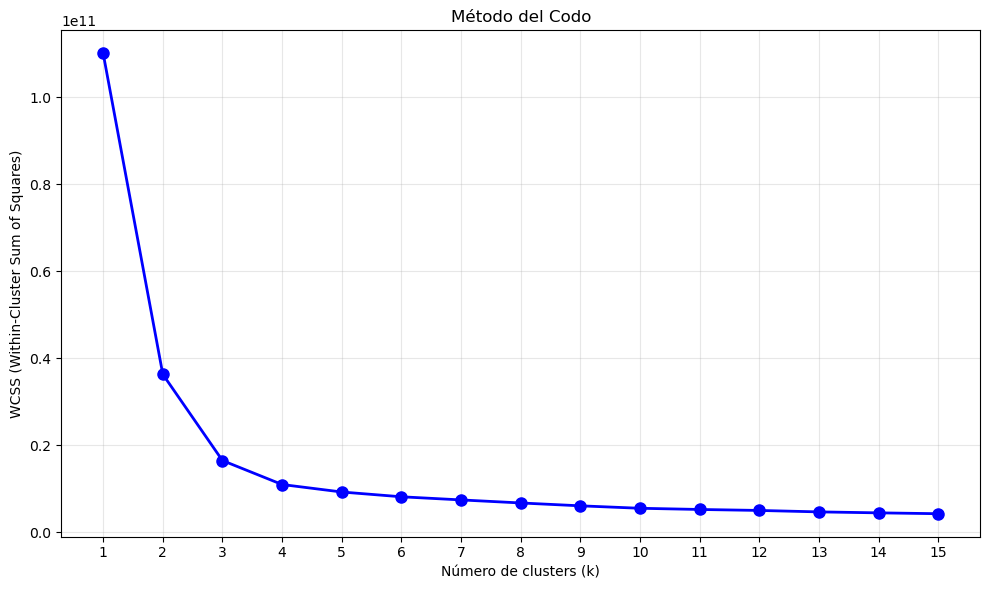

WCSS values for each k:
k=1: WCSS=110042783328.20
k=2: WCSS=36262470419.85
k=3: WCSS=16439609055.88
k=4: WCSS=10928733289.45
k=5: WCSS=9208490110.90
k=6: WCSS=8108994552.12
k=7: WCSS=7389912335.95
k=8: WCSS=6689988007.31
k=9: WCSS=6031449836.64
k=10: WCSS=5467992298.17
k=11: WCSS=5193832088.11
k=12: WCSS=4969454714.15
k=13: WCSS=4636458859.10
k=14: WCSS=4414721889.77
k=15: WCSS=4219474459.58


In [66]:
#aquí debe ir el código del Método Elbow - Codo
from sklearn.cluster import KMeans

df_kmeans = df.select_dtypes(include=[np.number]).dropna()

wcss = []
k_range = range(1, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_kmeans)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Método del Codo')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("WCSS values for each k:")
for k, w in zip(k_range, wcss):
    print(f"k={k}: WCSS={w:.2f}")



### Cuestiones
1. ¿En qué valor de `k` parece estar el “codo”?
    -   En el valor 3 de k parece estar el "codo" ya que la curva ya no es tan pronunciada lo que nos dice que añadir más clusters a partir 
        de ahí no compensa el incremento de complejidad.

2. ¿Ese valor coincide con lo que observabas en la gráfica?
    -   Sí, coincide. En la gráfica de dispersión inicial (ingreso_anual vs gasto_ocio) ya se podían intuir tres grupos naturales de familias: las de ingresos bajos, las de ingresos medios y las de ingresos altos. El método del codo confirma cuantitativamente lo que se percibía visualmente: k=3 captura la estructura principal de los datos sin sobreajustar.

3. ¿Crees que hay una única respuesta correcta?
    -   No, no existe una única respuesta correcta. El método del codo es una heurística, no una regla matemática exacta.
    -   El método del codo sugiere k=3 como punto de equilibrio entre simplicidad y calidad de agrupación, pero la decisión final siempre requiere criterio y contexto.

## 9. ¿Por qué es importante escalar?

K-Means trabaja con distancias.
Si una variable tiene valores mucho más grandes que otra, dominará el resultado.

Lo puedes comprobar ampliando las variables:
- ingresos,
- varios tipos de gasto,
- ahorro.

In [67]:
columnas_modelo = [
    "ingreso_anual",
    "gasto_vivienda",
    "gasto_alimentacion",
    "gasto_transporte",
    "gasto_ocio",
    "gasto_salud",
    "gasto_educacion",
    "ahorro"
]

X = df[columnas_modelo]
X.head()

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


In [68]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
ingreso_anual,300.0,33868.820233,17169.230976,12000.00,18733.9400,30962.135,43409.1550,81330.33
gasto_vivienda,300.0,10126.577700,5234.255944,3187.00,5650.7275,9284.880,13350.4350,24990.75
gasto_alimentacion,300.0,6260.093467,3430.261648,1885.87,3411.5100,5600.565,8076.6900,17029.32
gasto_transporte,300.0,3399.638000,2017.642022,655.81,1834.5550,2815.020,4635.6850,11019.70
gasto_ocio,300.0,2859.993233,2149.923506,0.00,1447.8325,2266.845,3805.7775,11935.32
gasto_salud,300.0,2008.935567,1284.444677,0.00,1141.7275,1685.030,2523.5525,7893.35
gasto_educacion,300.0,2383.226000,1634.672553,0.00,1264.5775,1989.195,3086.0750,9547.87
ahorro,300.0,6830.356533,4589.870824,-1084.03,3449.3725,5539.920,9734.2025,25817.67


Observa que:
- `ingreso_anual` tiene una magnitud muy superior,
- y algunas variables de gasto tienen escalas bastante distintas.

Por eso vamos a comparar el clustering:
1. **sin escalado**
2. **con escalado**

In [69]:
modelo_sin_escalar = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_sin_escalar = modelo_sin_escalar.fit_predict(X)

df["cluster_sin_escalar"] = labels_sin_escalar
df.groupby("cluster_sin_escalar")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_sin_escalar,,,,,,,,
0,36687.48,11021.95,6686.03,3819.94,2944.20,2163.72,2574.52,7477.13
1,61909.99,18339.81,11673.12,5979.66,5293.97,3645.94,4334.50,12642.99
2,18541.72,5578.23,3401.37,1853.22,1665.37,1122.42,1320.78,3600.33


In [70]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

modelo_escalado = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_escalado = modelo_escalado.fit_predict(X_escalado)

df["cluster_escalado"] = labels_escalado
df.groupby("cluster_escalado")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_escalado,,,,,,,,
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


## 10. Comparación de resultados

Ahora compara las medias de cada cluster:
- ¿son más coherentes tras escalar?
    -   Sí. Sin escalar, el ingreso anual domina el cálculo de distancias por tener valores mucho más grandes. Al escalar, todas las variables pesan igual y los clusters reflejan mejor el comportamiento completo de cada familia.

- ¿parece que el modelo recoge mejor el comportamiento global de las familias?
    -   Sí. La distribución tras escalar es más equilibrada (51 / 130 / 119 vs 110 / 60 / 130) y los centroides muestran patrones coherentes en todas las variables: familias con ingresos altos también gastan y ahorran más en todas las categorías, sin distorsiones.

In [71]:
print("Distribución de familias por cluster (sin escalar):")
print(df["cluster_sin_escalar"].value_counts().sort_index())

print("\nDistribución de familias por cluster (escalado):")
print(df["cluster_escalado"].value_counts().sort_index())

Distribución de familias por cluster (sin escalar):
cluster_sin_escalar
0    110
1     60
2    130
Name: count, dtype: int64

Distribución de familias por cluster (escalado):
cluster_escalado
0     51
1    130
2    119
Name: count, dtype: int64


## 11. Centroides del modelo escalado

Como los centroides escalados son difíciles de interpretar directamente,
vamos a devolverlos a la escala original.

In [72]:
centroides_escalados = modelo_escalado.cluster_centers_
centroides_originales = scaler.inverse_transform(centroides_escalados)
pd.DataFrame(centroides_originales, columns=columnas_modelo).round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


### Cuestiones
1. ¿Qué clúster representa familias con más ingresos?
    -   El cluster 0, con una media de 63.685€ anuales.

2. ¿Qué clúster parece más vulnerable?
    -   El cluster 1, con los ingresos más bajos (18.549€) y el menor ahorro (3.638€).

3. ¿Cuál parece más ahorrador?
    -   El cluster 0, que ahorra de media 12.078€, lo que representa aproximadamente un 19% de sus ingresos, proporción similar a los 
        otros clusters, pero en términos absolutos es el mayor.

4. ¿Ves relación entre ingresos altos y mayor gasto en algunas categorías?
    -   Sí. El cluster 0 lidera en todas las categorías de gasto: vivienda (18.924€), alimentación (12.117€), ocio (5.740€) y 
        educación (4.616€). A más ingresos, más gasto en todas las partidas.


## 12. Interpretación final de clusters

Redacta una interpretación breve de cada cluster.

Modelo de ejemplo:

- **Cluster A**: familias acomodadas, ingresos altos, gastan más en todas las categorías y tienen el mayor ahorro. Perfil estable y con capacidad económica holgada.
- **Cluster B**: familias vulnerables, ingresos bajos, gastos reducidos en todo y poco ahorro. Son las más expuestas ante imprevistos económicos. 
- **Cluster C**: familias estables, ingresos intermedios, gastos moderados y ahorro razonable. Representan el perfil más común y equilibrado.

Lo importante no es solo ejecutar K-Means, sino **dar sentido a los grupos**.

## 13. Actividad de ampliación

Prueba alguna de estas variantes:
- usar solo ingresos y ahorro,
- usar ingresos, vivienda, alimentación y ocio,
- probar `k = 4`,
- comparar resultados con y sin la variable `ahorro`,
- detectar si algunos hogares quedan en clusters poco claros.

Esto te ayudará a entender que en Aprendizaje No Supervisado las decisiones sobre variables y preparación de datos cambian el resultado.
> Resumiendo: K-Means no “descubre la verdad”; propone agrupaciones a partir de cómo le damos los datos.